<a href="https://colab.research.google.com/github/marvinjc/proyecto_final_CD/blob/main/cd_final_proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto final: Aguas superficiales CONAGUA 2020
Limpieza, EDA, preparación (Pipeline) y K-means geográfico


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler,FunctionTransformer

sns.set_theme(style="whitegrid")
RUTA_SITIOS = "/content/drive/MyDrive/CienciaDeDatos/ProyectoFinal/DataSets/Datos_de_calidad_del_agua_de_sitios_de_monitoreo_de_aguas_superficiales_2020.csv"
RUTA_ESCALAS = "/content/drive/MyDrive/CienciaDeDatos/ProyectoFinal/DataSets/Escalas_superficial.csv"

## 1. Carga e inspección inicial

In [ ]:
df_crudo = pd.read_csv(RUTA_SITIOS, encoding="latin-1")
print(df_crudo.shape)
df_crudo.head()

(4141, 55)


,CLAVE,SITIO,ORGANISMO_DE_CUENCA,ESTADO,MUNICIPIO,CUENCA,CUERPO DE AGUA,TIPO,SUBTIPO,LONGITUD,...,CONTAMINANTES,CUMPLE_CON_DBO,CUMPLE_CON_DQO,CUMPLE_CON_SST,CUMPLE_CON_CF,CUMPLE_CON_E_COLI,CUMPLE_CON_ENTEROC,CUMPLE_CON_OD,CUMPLE_CON_TOX,GRUPO
0,DLAGU8,PRESA EL SAUCILLO 100M AGUAS ARRIBA DE LA CORTINA,LERMA SANTIAGO PACIFICO,AGUASCALIENTES,RINCON DE ROMOS,RIO SAN PEDRO,PRESA EL SAUCILLO,LENTICO,PRESA,-102.33911,...,"DQO,CF,",SI,NO,SI,NO,SI,ND,SI,SI,LENTICO
1,DLBAJ100,"LOS CABOS SEG 22, 2 ISA10B",PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN JOSE DEL CABO,OCEANO PACIFICO,COSTERO,OCEANO-MAR,-109.84290,...,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
2,DLBAJ101,"LOS CABOS SEG 22, 1 ISA10B",PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,OCEANO PACIFICO,COSTERO,OCEANO-MAR,-109.86442,...,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
3,DLBAJ102,LOS CABOS 3,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,BAHIA SAN LUCAS,COSTERO,BAHIA,-109.88604,...,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
4,DLBAJ103,LOS CABOS 1,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,BAHIA SAN LUCAS,COSTERO,BAHIA,-109.89657,...,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO


In [ ]:
df_crudo.sample(5, random_state=42)

,CLAVE,SITIO,ORGANISMO_DE_CUENCA,ESTADO,MUNICIPIO,CUENCA,CUERPO DE AGUA,TIPO,SUBTIPO,LONGITUD,...,CONTAMINANTES,CUMPLE_CON_DBO,CUMPLE_CON_DQO,CUMPLE_CON_SST,CUMPLE_CON_CF,CUMPLE_CON_E_COLI,CUMPLE_CON_ENTEROC,CUMPLE_CON_OD,CUMPLE_CON_TOX,GRUPO
2083,OCGCE3239,FELIPE CARRILLO PUERTO,GOLFO CENTRO,VERACRUZ DE IGNACIO DE LA LLAVE,MARTINEZ DE LA TORRE,RIO NAUTLA,RIO BOBOS,LOTICO (HUMEDAL),RIO,-96.95467,...,"CF,E_COLI,",SI,SI,SI,NO,NO,ND,SI,SI,LOTICO
1965,OCFSU3124,"PUERTO MADERO SEG 73, 3 ISA8",FRONTERA SUR,CHIAPAS,TAPACHULA,PUERTO MADERO,OCEANO PACIFICO,COSTERO,OCEANO-MAR,-92.41338,...,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
1582,DLTAB5561,MANATI 10,FRONTERA SUR,TABASCO,MACUSPANA,Chilapa,NaN,LOTICO,NaN,-92.30760,...,"CF,",SI,SI,SI,NO,SI,ND,ND,SI,LOTICO
296,DLDUR676M1,PRESA SANTIAGO BAYACORA,PACIFICO NORTE,DURANGO,DURANGO,RIO SANTIAGO BAYACORA,PRESA SANTIAGO BAYACORA,LENTICO (HUMEDAL),PRESA,-104.67751,...,NaN,SI,SI,SI,SI,SI,ND,SI,SI,LENTICO
149,DLCHI294,PLANTA NORTE,RIO BRAVO,CHIHUAHUA,JUAREZ,RIO BRAVO 1,CANAL,LOTICO,CANAL,-106.37040,...,NaN,SI,SI,SI,SI,SI,ND,SI,SI,LOTICO


In [ ]:
print(df_crudo.shape)
df_crudo.info(verbose=True, show_counts=True)

(4141, 55)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4141 entries, 0 to 4140
Data columns (total 55 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CLAVE                   3493 non-null   object 
 1   SITIO                   3493 non-null   object 
 2   ORGANISMO_DE_CUENCA     3493 non-null   object 
 3   ESTADO                  3493 non-null   object 
 4   MUNICIPIO               3493 non-null   object 
 5   CUENCA                  3492 non-null   object 
 6   CUERPO DE AGUA          3479 non-null   object 
 7   TIPO                    3493 non-null   object 
 8   SUBTIPO                 3479 non-null   object 
 9   LONGITUD                3493 non-null   float64
 10  LATITUD                 3493 non-null   float64
 11  PERIODO                 3493 non-null   float64
 12  DBO_mg/L                2581 non-null   object 
 13  CALIDAD_DBO             2581 non-null   object 
 14  DQO_mg/L                2581 

In [ ]:
escalas = pd.read_csv(RUTA_ESCALAS, encoding="latin-1")
escalas.head(12)

,CALIDAD DEL AGUA PARA TOXICIDAD,CRITERIO,DESCRIPCION
0,No t¢xico,TOX menor a 1,Agua no contaminada.Toxicidad no detectable.
1,Toxicidad baja,TOX mayor o igual a 1 y menor o igual a 1.33,Toxicidad baja
2,Toxicidad moderada,TOX mayor de 1.33 y menor a 5,Toxicidad moderada
3,Toxicidad alta,TOX mayor o igual a 5,Toxicidad alta
4,CALIDAD DEL AGUA PARA SST,CRITERIO,DESCRIPCION
5,Excelente,SST menor o igual a 25,"Clase de excepci¢n, muy buena calidad."
6,Buena calidad,SST mayor de 25 y menor o igual a 75,Aguas superficiales con bajo contenido de soli...
7,Aceptable,SST mayor de 75 y menor o igual a 150,Aguas superficiales con indicio de contaminaci...
8,Contaminada,SST mayor de 150 y menor o igual a 400,Aguas superficiales de mala calidad con descar...
9,Fuertemente contaminada,SST mayor de 400,Aguas superficiales con fuerte impacto de desc...


## 2. Limpieza de datos
Busqueda de nulos, valores mal escritos (`<10`, `ND`) y sustitucion.

- `ND` / vacio -> NaN (no se midio; no se inventa un valor).
- `<10` -> 5: convencion (límite de detección)LD/2 para datos censurados. **No es la medicion exacta**; CONAGUA solo reporta que era menor al limite. Se usa para poder hacer describe, boxplot y correlacion.
- `>100` -> 100: se usa el limite; se pierde la distincion "mayor que".
- LATITUD / LONGITUD o SEMAFORO faltante: se elimina, **no se imputa**.

In [ ]:
nulos_antes = df_crudo.isna().sum()
nulos_antes = nulos_antes[nulos_antes > 0].sort_values(ascending=False)
pd.DataFrame({
    "nulos": nulos_antes,
    "porcentaje": (nulos_antes / len(df_crudo) * 100).round(1),
})

,nulos,porcentaje
TOX_FIS_FON_15_UT,4141,100.0
CALIDAD_TOX_FIS_FON_15,4141,100.0
TOX_D_48_FON_UT,4141,100.0
CALIDAD_TOX_D_48_FON,4141,100.0
OD_PORC_MED,3654,88.2
CALIDAD_OD_PORC_MED,3654,88.2
CALIDAD TOX_D_48_SUP,3379,81.6
TOX_D_48_SUP_UT,3379,81.6
ENTEROC_NMP_100mL,3237,78.2
CALIDAD_ENTEROC,3237,78.2


In [ ]:
Y = "SEMAFORO"
COLS_GEO = ["LONGITUD", "LATITUD"]
COLORES_SEMAFORO = {"Verde": "#2e7d32", "Amarillo": "#f9a825", "Rojo": "#c62828"}

COLS_LAB = [
    "DBO_mg/L", "DQO_mg/L", "SST_mg/L",
    "COLI_FEC_NMP_100mL", "E_COLI_NMP_100mL", "ENTEROC_NMP_100mL",
    "OD_PORC", "OD_PORC_SUP", "OD_PORC_MED", "OD_PORC_FON",
    "TOX_D_48_UT", "TOX_V_15_UT", "TOX_D_48_SUP_UT", "TOX_FIS_SUP_15_UT",
]

X_NUMERICAS = [
    "DBO_mg/L", "DQO_mg/L", "SST_mg/L",
    "COLI_FEC_NMP_100mL", "E_COLI_NMP_100mL", "ENTEROC_NMP_100mL",
    "OD_PORC", "OD_PORC_SUP",
]

def a_numero(valor):
    """'54.08' -> 54.08 | '<10' -> 5 (LD/2, convencion) | '>100' -> 100 | ND/vacio -> NaN"""
    if pd.isna(valor):
        return np.nan
    texto = str(valor).strip()
    if texto == "" or texto.upper() == "ND":
        return np.nan
    texto = texto.replace(",", "")
    if texto.startswith("<"):
        try:
            return float(texto[1:]) / 2.0
        except ValueError:
            return np.nan
    if texto.startswith(">"):
        try:
            return float(texto[1:])
        except ValueError:
            return np.nan
    try:
        return float(texto)
    except ValueError:
        return np.nan

In [ ]:
df = df_crudo.dropna(subset=["CLAVE"]).copy()
df["CLAVE"] = df["CLAVE"].astype(str).str.strip()
df = df[df["CLAVE"] != ""].copy()

for col in COLS_LAB + COLS_GEO:
    if col in df.columns:
        df[col] = df[col].map(a_numero)

df[Y] = df[Y].astype(str).str.strip().str.title()
df.loc[df[Y].isin(["Nan", "Nd", "None", ""]), Y] = np.nan

if "GRUPO" in df.columns:
    df["GRUPO"] = df["GRUPO"].astype(str).str.strip().str.upper()

n0 = len(df)
df = df.dropna(subset=COLS_GEO).copy()
print("Eliminadas por lat/lon faltante:", n0 - len(df))

n1 = len(df)
df = df.dropna(subset=[Y]).copy()
print("Eliminadas por SEMAFORO faltante:", n1 - len(df))
print("Sitios listos:", len(df))
df[COLS_LAB[:5] + COLS_GEO + [Y]].head()

Eliminadas por lat/lon faltante: 0
Eliminadas por SEMAFORO faltante: 0
Sitios listos: 3493


,DBO_mg/L,DQO_mg/L,SST_mg/L,COLI_FEC_NMP_100mL,E_COLI_NMP_100mL,LONGITUD,LATITUD,SEMAFORO
0,6.0,54.08,13.7500,1162.0,98.0,-102.33911,22.24730,Rojo
1,NaN,NaN,5.0000,NaN,NaN,-109.84290,22.90473,Verde
2,NaN,NaN,5.0000,NaN,NaN,-109.86442,22.89880,Verde
3,NaN,NaN,13.9667,NaN,NaN,-109.88604,22.89609,Verde
4,NaN,NaN,5.0000,NaN,NaN,-109.89657,22.87694,Verde


In [ ]:
nulos_despues = df.isna().sum()
nulos_despues = nulos_despues[nulos_despues > 0].sort_values(ascending=False)
pd.DataFrame({
    "nulos": nulos_despues,
    "porcentaje": (nulos_despues / len(df) * 100).round(1),
})

,nulos,porcentaje
TOX_FIS_FON_15_UT,3493,100.0
CALIDAD_TOX_FIS_FON_15,3493,100.0
CALIDAD_TOX_D_48_FON,3493,100.0
TOX_D_48_FON_UT,3493,100.0
OD_PORC_MED,3006,86.1
CALIDAD_OD_PORC_MED,3006,86.1
TOX_D_48_SUP_UT,2731,78.2
CALIDAD TOX_D_48_SUP,2731,78.2
CALIDAD_ENTEROC,2589,74.1
ENTEROC_NMP_100mL,2589,74.1


### Nulos por GRUPO
Comprobar si un parametro no se midio en COSTERO / LOTICO / LENTICO **antes** de afirmarlo.

In [ ]:
nulos_grupo = (
    df.groupby("GRUPO")[X_NUMERICAS]
    .agg(lambda serie: serie.isna().mean() * 100)
    .round(1)
)
nulos_grupo

,DBO_mg/L,DQO_mg/L,SST_mg/L,COLI_FEC_NMP_100mL,E_COLI_NMP_100mL,ENTEROC_NMP_100mL,OD_PORC,OD_PORC_SUP
GRUPO,,,,,,,,
COSTERO,91.3,91.3,0.1,91.3,91.3,9.4,94.8,9.0
LENTICO,1.0,1.0,0.0,0.8,0.8,99.2,100.0,2.2
LOTICO,0.2,0.2,0.2,0.2,0.2,99.8,1.5,99.8


## 3. Análisis exploratorio (EDA (Análisis Exploratorio de Datos.))

In [ ]:
cols_eda = [c for c in X_NUMERICAS if c in df.columns]
cols_corr = cols_eda + COLS_GEO
print(cols_eda)

['DBO_mg/L', 'DQO_mg/L', 'SST_mg/L', 'COLI_FEC_NMP_100mL', 'E_COLI_NMP_100mL', 'ENTEROC_NMP_100mL', 'OD_PORC', 'OD_PORC_SUP']


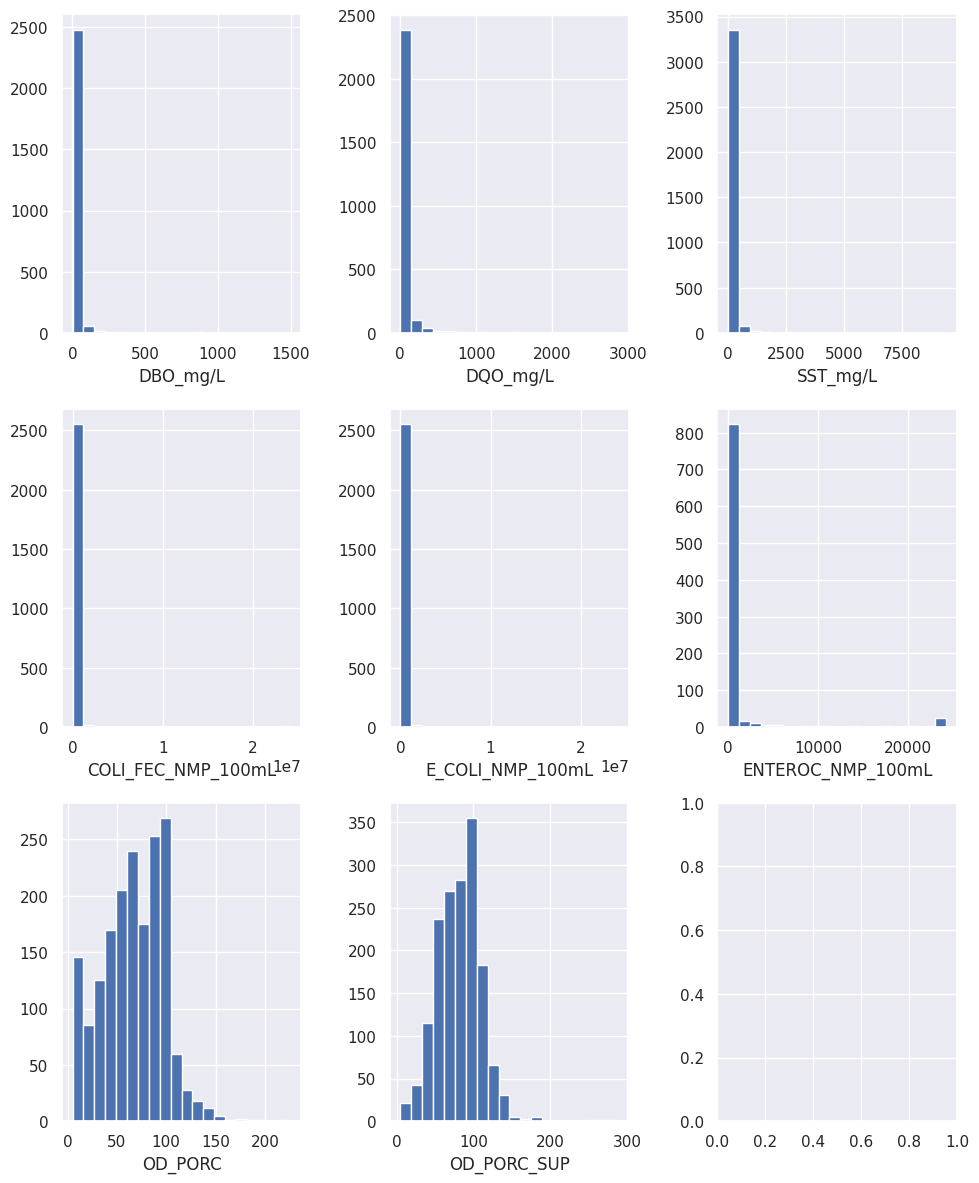

In [ ]:
sns.set(rc={"figure.figsize": (10, 12)})
fig, axes = plt.subplots(3, 3)
for k, col in enumerate(cols_eda):
    plt.subplot(3, 3, k + 1)
    plt.hist(df[col].dropna(), bins=20)
    plt.xlabel(col)
plt.tight_layout()
plt.show()

In [ ]:
desc = df[cols_corr].describe(percentiles=[0.25, 0.5, 0.75]).T
desc["media"] = df[cols_corr].mean()
desc["mediana"] = df[cols_corr].median()
desc["rango"] = desc["max"] - desc["min"]
desc[["count", "mean", "mediana", "std", "min", "25%", "50%", "75%", "max", "rango"]].round(2)

,count,mean,mediana,std,min,25%,50%,75%,max,rango
DBO_mg/L,2581.0,16.41,2.63,65.25,1.00,1.00,2.63,10.00,1500.00,1499.00
DQO_mg/L,2581.0,63.25,27.01,150.23,5.00,11.87,27.01,57.00,2871.25,2866.25
SST_mg/L,3489.0,100.89,24.30,442.13,5.00,5.00,24.30,57.00,9430.00,9425.00
COLI_FEC_NMP_100mL,2582.0,95688.75,2400.00,1168887.30,1.50,342.00,2400.00,24000.00,24196000.00,24195998.50
E_COLI_NMP_100mL,2582.0,79337.48,424.00,1051334.13,1.50,40.00,424.00,6488.00,24196000.00,24195998.50
ENTEROC_NMP_100mL,904.0,1085.94,1.50,4306.11,1.50,1.50,1.50,63.00,24196.00,24194.50
OD_PORC,1797.0,66.53,68.30,31.99,5.00,44.30,68.30,91.60,226.10,221.10
OD_PORC_SUP,1619.0,81.41,84.10,28.68,5.00,61.20,84.10,99.95,289.00,284.00
LONGITUD,3493.0,-100.36,-99.80,6.12,-117.12,-103.88,-99.80,-96.86,-86.73,30.39
LATITUD,3493.0,21.05,20.15,3.89,14.53,18.40,20.15,22.83,32.71,18.17


In [ ]:
sesgo = pd.DataFrame({
    "media": df[cols_eda].mean(),
    "mediana": df[cols_eda].median(),
})
sesgo["diferencia"] = sesgo["media"] - sesgo["mediana"]
sesgo

,media,mediana,diferencia
DBO_mg/L,16.412246,2.63,13.782246
DQO_mg/L,63.250071,27.01,36.240071
SST_mg/L,100.887038,24.30,76.587038
COLI_FEC_NMP_100mL,95688.745352,2400.00,93288.745352
E_COLI_NMP_100mL,79337.475407,424.00,78913.475407
ENTEROC_NMP_100mL,1085.939934,1.50,1084.439934
OD_PORC,66.534224,68.30,-1.765776
OD_PORC_SUP,81.413650,84.10,-2.686350


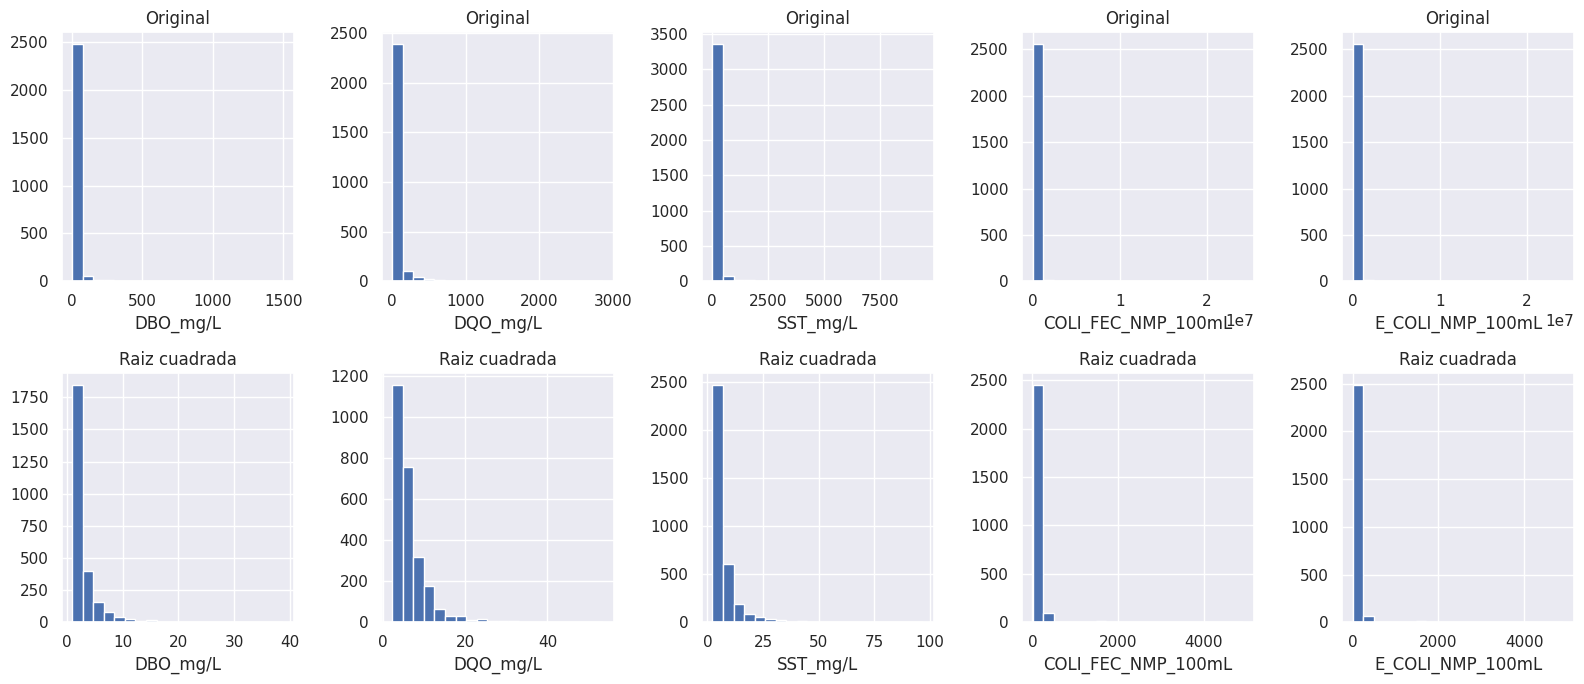

In [ ]:
cols_sesgo = [c for c in [
    "DBO_mg/L", "DQO_mg/L", "SST_mg/L",
    "COLI_FEC_NMP_100mL", "E_COLI_NMP_100mL",
] if c in df.columns]

sns.set(rc={"figure.figsize": (16, 7)})
fig, axes = plt.subplots(2, len(cols_sesgo))
for k, col in enumerate(cols_sesgo):
    tmp = df[col].dropna()
    tmp = tmp[tmp >= 0]
    plt.subplot(2, len(cols_sesgo), k + 1)
    plt.hist(tmp, bins=20)
    plt.xlabel(col)
    plt.title("Original")
    plt.subplot(2, len(cols_sesgo), k + 1 + len(cols_sesgo))
    plt.hist(np.sqrt(tmp), bins=20)
    plt.xlabel(col)
    plt.title("Raiz cuadrada")
plt.tight_layout()
plt.show()

In [ ]:
def contar_outliers_iqr(serie):
    datos = serie.dropna()
    q1, q3 = datos.quantile(0.25), datos.quantile(0.75)
    iqr = q3 - q1
    inf, sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((datos < inf) | (datos > sup)).sum())
    return n_out, inf, sup

filas = []
for col in cols_eda:
    n_out, inf, sup = contar_outliers_iqr(df[col])
    n_ok = df[col].notna().sum()
    filas.append({
        "variable": col,
        "n_validos": n_ok,
        "outliers": n_out,
        "porcentaje": round(100 * n_out / n_ok, 1) if n_ok else 0,
        "limite_inf": inf,
        "limite_sup": sup,
    })
pd.DataFrame(filas)

,variable,n_validos,outliers,porcentaje,limite_inf,limite_sup
0,DBO_mg/L,2581,328,12.7,-12.500,23.500
1,DQO_mg/L,2581,263,10.2,-55.825,124.695
2,SST_mg/L,3489,420,12.0,-73.000,135.000
3,COLI_FEC_NMP_100mL,2582,133,5.2,-35145.000,59487.000
4,E_COLI_NMP_100mL,2582,505,19.6,-9632.000,16160.000
5,ENTEROC_NMP_100mL,904,167,18.5,-90.750,155.250
6,OD_PORC,1797,6,0.3,-26.650,162.550
7,OD_PORC_SUP,1619,12,0.7,3.075,158.075


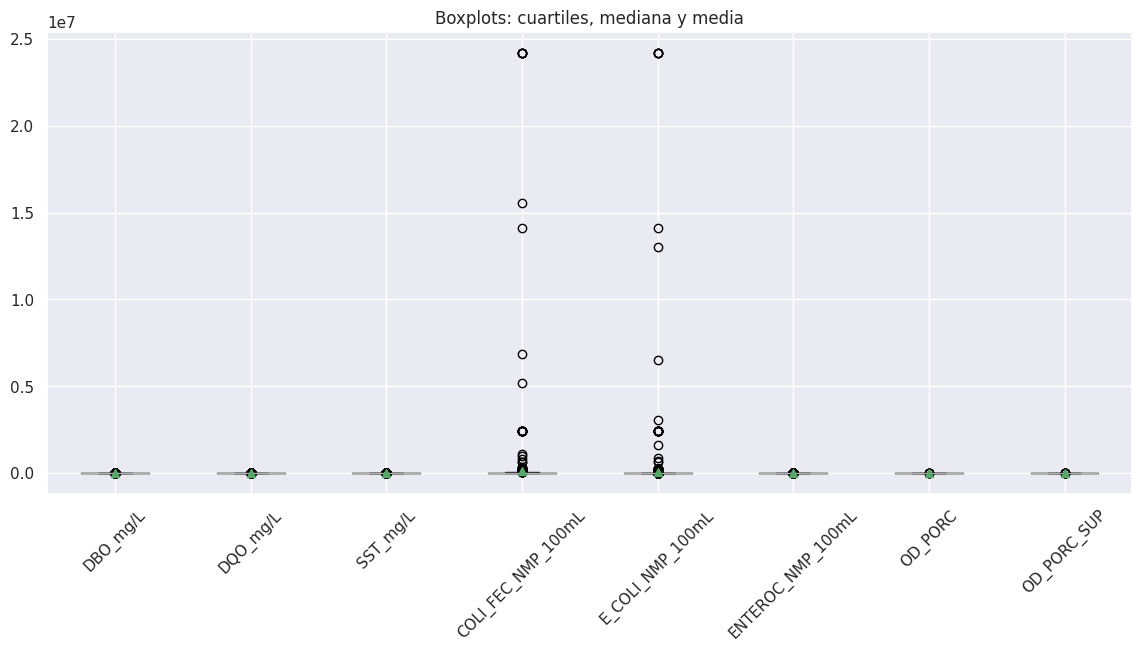

In [ ]:
sns.set(rc={"figure.figsize": (14, 6)})
df[cols_eda].boxplot(rot=45, showmeans=True)
plt.title("Boxplots: cuartiles, mediana y media")
plt.show()

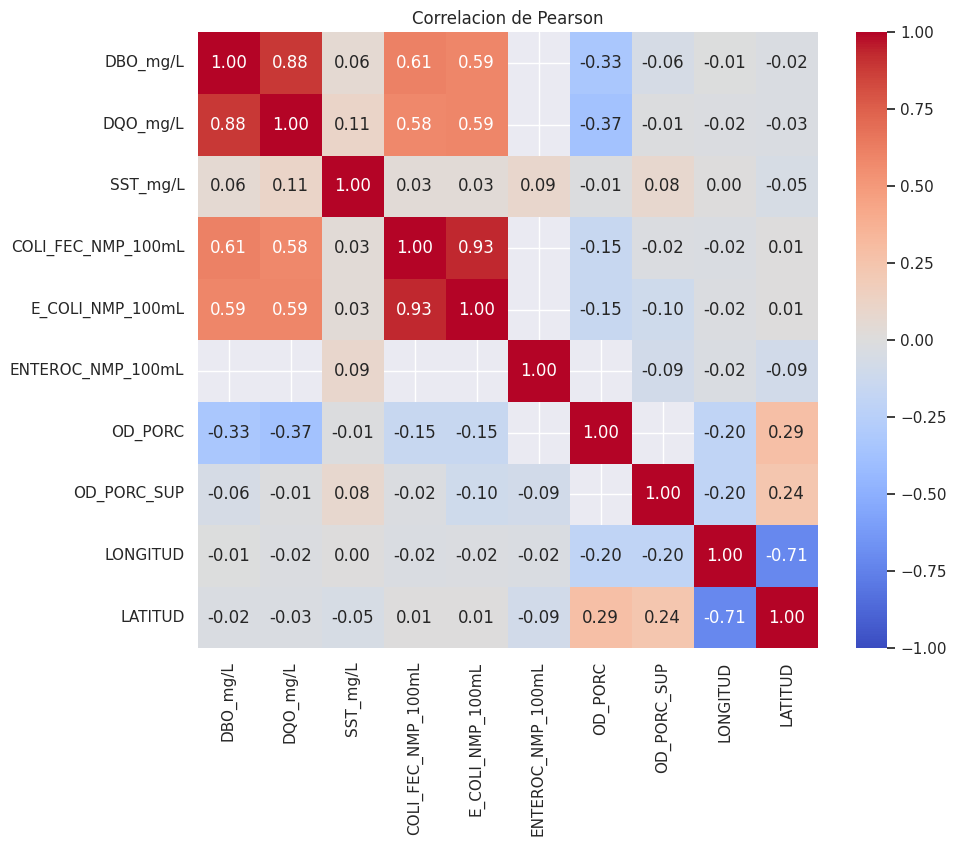

In [ ]:
corr = df[cols_corr].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlacion de Pearson")
plt.show()

## 4. Preparar los datos (Pipeline del Laboratorio 1)
Imputar mediana + MinMax + raiz en variables con sesgo.

Este bloque es la preparacion de **calidad** del Laboratorio 1. **NO entra a K-means**.
K-means usa solo latitud y longitud, sin imputar.
MinMax en lat/lon iguala el rango de ambos ejes para que uno no domine; la inercia no se interpreta en kilometros.

In [ ]:
num_prepro_pipeline = Pipeline(steps=[
    ("imputar", SimpleImputer(strategy="median")),
    ("escalar", MinMaxScaler(feature_range=(1, 2))),
])

num_raiz_pipeline = Pipeline(steps=[
    ("sqrt", FunctionTransformer(np.sqrt)),
])

columnasTransformer = ColumnTransformer(
    transformers=[
        ("num_prepro", num_prepro_pipeline, cols_eda),
        ("num_raiz", num_raiz_pipeline, cols_sesgo),
    ],
    remainder="drop",
)

X_prep = columnasTransformer.fit_transform(df[cols_eda])
print("Matriz preparada (calidad, NO se usa en K-means):", X_prep.shape)
pd.DataFrame(X_prep).describe().round(3)

Matriz preparada (calidad, NO se usa en K-means): (3493, 13)


,0,1,2,3,4,5,6,7,8,9,10,11,12
count,3493.000,3493.000,3493.000,3493.000,3493.000,3493.000,3493.000,3493.000,2581.000,2581.000,3489.000,2582.000,2582.000
mean,1.008,1.017,1.010,1.003,1.002,1.012,1.282,1.274,2.684,6.326,6.856,106.635,79.669
std,0.038,0.045,0.047,0.042,0.037,0.093,0.104,0.069,3.035,4.821,7.341,290.431,270.220
min,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,2.236,2.236,1.225,1.225
25%,1.000,1.004,1.000,1.000,1.000,1.000,1.282,1.279,1.000,3.445,2.236,18.493,6.325
50%,1.001,1.008,1.002,1.000,1.000,1.000,1.286,1.279,1.622,5.197,4.930,48.990,20.591
75%,1.004,1.013,1.006,1.000,1.000,1.000,1.291,1.279,3.162,7.550,7.550,154.919,80.548
max,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,38.730,53.584,97.108,4918.943,4918.943


In [ ]:
geo_pipeline = Pipeline(steps=[
    ("escalar", MinMaxScaler(feature_range=(0, 1))),
])
X_geo = df[COLS_GEO].copy()
X_geo_scaled = geo_pipeline.fit_transform(X_geo)
print(X_geo_scaled.shape)
print("MinMax iguala ejes; la inercia no son kilometros.")
print("Rango lon:", float(X_geo["LONGITUD"].min()), float(X_geo["LONGITUD"].max()))
print("Rango lat:", float(X_geo["LATITUD"].min()), float(X_geo["LATITUD"].max()))

(3493, 2)
MinMax iguala ejes; la inercia no son kilometros.
Rango lon: -117.12403 -86.73215
Rango lat: 14.53491 32.7065


## 5. K-means: calidad vs ubicacion geografica
Solo LATITUD y LONGITUD. La calidad se compara despues con SEMAFORO.

k se elige con el **codo** (se reporta silueta). k=3 se muestra solo como comparacion:
tres colores de semaforo no implican tres regiones geograficas.

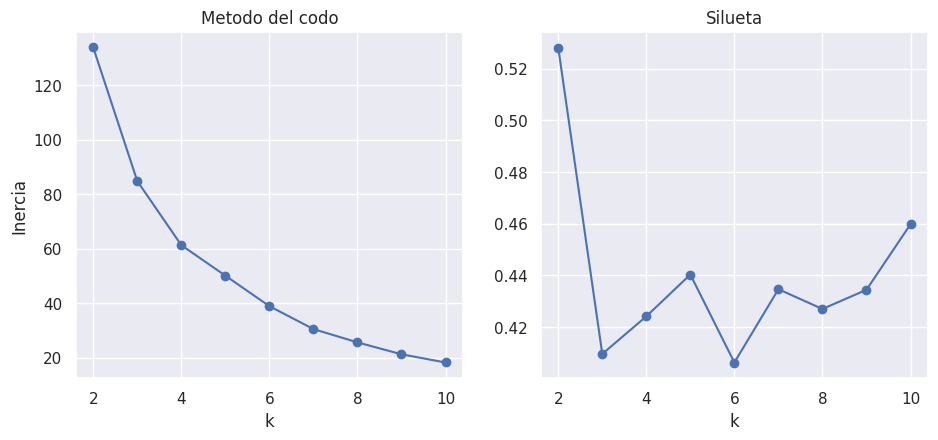

k=2  inercia=133.8  silhouette=0.528
k=3  inercia=84.8  silhouette=0.410
k=4  inercia=61.3  silhouette=0.424
k=5  inercia=50.1  silhouette=0.440
k=6  inercia=38.9  silhouette=0.406
k=7  inercia=30.5  silhouette=0.435
k=8  inercia=25.6  silhouette=0.427
k=9  inercia=21.2  silhouette=0.434
k=10  inercia=18.2  silhouette=0.460


In [ ]:
ks, inercias, siluetas = list(range(2, 11)), [], []

for k in ks:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(X_geo_scaled)
    inercias.append(modelo.inertia_)
    siluetas.append(silhouette_score(X_geo_scaled, etiquetas))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(ks, inercias, marker="o")
axes[0].set_title("Metodo del codo")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inercia")
axes[1].plot(ks, siluetas, marker="o")
axes[1].set_title("Silueta")
axes[1].set_xlabel("k")
plt.show()

for k, inn, sil in zip(ks, inercias, siluetas):
    print(f"k={k}  inercia={inn:.1f}  silhouette={sil:.3f}")

In [ ]:
def k_codo_geometrico(ks, inercias):
    p1 = np.array([float(ks[0]), float(inercias[0])])
    p2 = np.array([float(ks[-1]), float(inercias[-1])])
    d = p2 - p1
    norma = np.linalg.norm(d)
    dist = [abs(d[0] * (p1[1] - inn) - d[1] * (p1[0] - k)) / norma for k, inn in zip(ks, inercias)]
    return int(ks[int(np.argmax(dist))])

k_final = k_codo_geometrico(ks, inercias)
k_sil = int(ks[int(np.argmax(siluetas))])
print("k codo (se usa en el mapa):", k_final)
print("k mejor silueta:", k_sil)
print("k=3 es solo comparacion; no se elige porque el semaforo tenga 3 colores.")

modelo = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df["cluster"] = modelo.fit_predict(X_geo_scaled)
centroides = geo_pipeline.named_steps["escalar"].inverse_transform(modelo.cluster_centers_)

print("Tamano de cada cluster:")
print(df["cluster"].value_counts().sort_index())
print("Conteos:")
print(pd.crosstab(df["cluster"], df[Y]))
print("Porcentaje dentro de cada cluster:")
pct = pd.crosstab(df["cluster"], df[Y], normalize="index").mul(100).round(1)
print(pct)

print("\nComparacion k=3 (referencia):")
print(pd.crosstab(
    KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_geo_scaled),
    df[Y],
    normalize="index",
).mul(100).round(1))

print("\nDiferencias observadas (no es una prueba ni un umbral fijo):")
print(
    f"% rojo: {pct['Rojo'].min():.1f} a {pct['Rojo'].max():.1f} "
    f"(dif. {pct['Rojo'].max() - pct['Rojo'].min():.1f})"
)
print(
    f"% verde: {pct['Verde'].min():.1f} a {pct['Verde'].max():.1f} "
    f"(dif. {pct['Verde'].max() - pct['Verde'].min():.1f})"
)

k codo (se usa en el mapa): 4
k mejor silueta: 2
k=3 es solo comparacion; no se elige porque el semaforo tenga 3 colores.
Tamano de cada cluster:
cluster
0     668
1    1641
2     934
3     250
Name: count, dtype: int64
Conteos:
SEMAFORO  Amarillo  Rojo  Verde
cluster                        
0              287   114    267
1              527   739    375
2              271   183    480
3               50    55    145
Porcentaje dentro de cada cluster:
SEMAFORO  Amarillo  Rojo  Verde
cluster                        
0             43.0  17.1   40.0
1             32.1  45.0   22.9
2             29.0  19.6   51.4
3             20.0  22.0   58.0

Comparacion k=3 (referencia):
SEMAFORO  Amarillo  Rojo  Verde
row_0                          
0             31.6  27.6   40.8
1             29.2  16.9   53.9
2             34.4  39.2   26.4

Diferencias observadas (no es una prueba ni un umbral fijo):
% rojo: 17.1 a 45.0 (dif. 27.9)
% verde: 22.9 a 58.0 (dif. 35.1)


## 6. Visualización: mapa de México

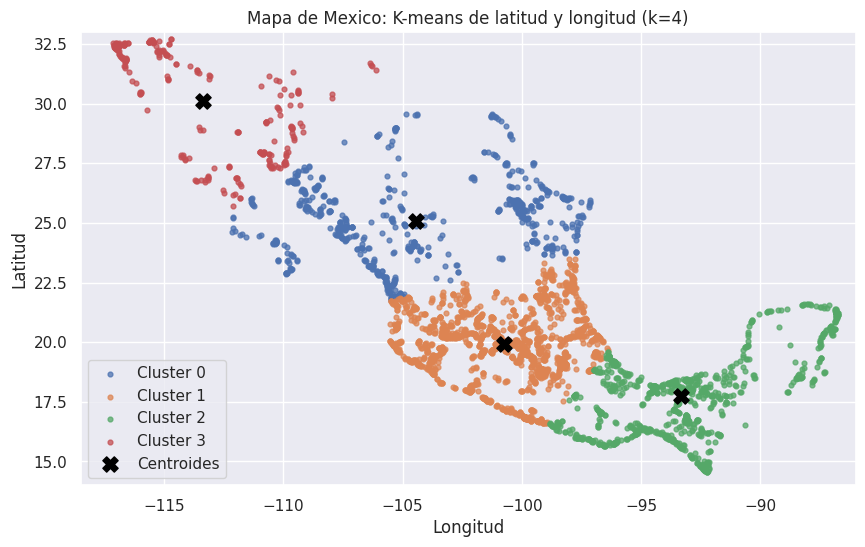

In [ ]:
def limites_mexico(ax):
    ax.set_xlim(-118.5, -86.0)
    ax.set_ylim(14.0, 33.0)
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    ax.set_aspect("equal", adjustable="box")

fig, ax = plt.subplots(figsize=(10, 8))
for i in range(k_final):
    sub = df[df["cluster"] == i]
    ax.scatter(sub["LONGITUD"], sub["LATITUD"], s=12, alpha=0.75, label=f"Cluster {i}")
ax.scatter(centroides[:, 0], centroides[:, 1], c="black", marker="X", s=120, label="Centroides")
limites_mexico(ax)
ax.legend(loc="lower left")
ax.set_title(f"Mapa de Mexico: K-means de latitud y longitud (k={k_final})")
plt.show()

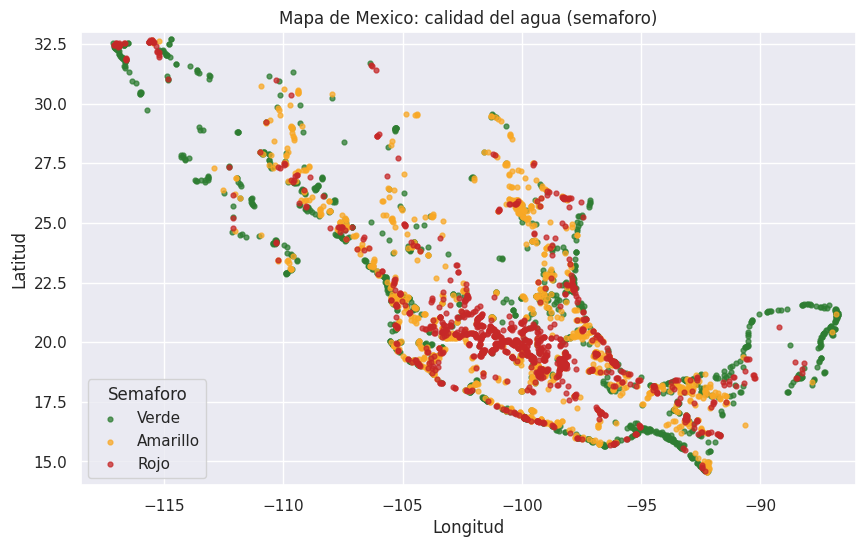

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
for clase, color in COLORES_SEMAFORO.items():
    sub = df[df[Y] == clase]
    ax.scatter(sub["LONGITUD"], sub["LATITUD"], c=color, s=12, alpha=0.75, label=clase)
limites_mexico(ax)
ax.legend(loc="lower left", title="Semaforo")
ax.set_title("Mapa de Mexico: calidad del agua (semaforo)")
plt.show()

## 7. Conclusiones

1. **Limpieza.** Las mediciones venian como texto (`<10`, `ND`). Se convirtieron con la convencion LD/2 (no es la medicion exacta; permite el EDA). Se eliminaron filas sin CLAVE, sin coordenadas o sin semaforo. Lat/lon no se imputaron. Los nulos que quedan se comprobaron por GRUPO (celda de % nulos): COSTERO casi no tiene DBO; LOTICO/LENTICO casi no tienen enterococos.

2. **EDA.** Varias variables tienen media mayor que la mediana (sesgo positivo), sobre todo bacteriologia y materia organica. Los boxplots muestran outliers. Hay correlacion fuerte DBO-DQO y coliformes-E. coli. Lat/lon casi no correlacionan con las mediciones.

3. **K-means.** Se agrupo solo con latitud y longitud. k se eligio por el codo, no porque el semaforo tenga 3 colores (k=3 es solo comparacion). Los clusters son regiones, no grupos de buena/mala calidad. El cruce con SEMAFORO muestra diferencias de porcentajes entre zonas; son diferencias observadas, no una prueba estadistica. El Pipeline de calidad del Laboratorio 1 no se uso para agrupar.

4. **Mapas.** Mismos puntos: uno por cluster y otro por semaforo. Si se parecen, calidad y region van juntas; si el semaforo esta salpicado, latitud y longitud no bastan para explicar la calidad.